# LIF Neuron model definition & recording.
In this notebook, our goal is to demonstrate a commonly-used neuron model in Spiking Neural Networks (SNNs), the Leaky Integrate-and-Fire (LIF). We define a network with a single LIF neuron, and export it for generating a dataflow accelerator with. This notebook covers:

1. A brief description of the neuron model with further resources.
2. Setting up event-based datasets.
3. Defining the LIF neuron in JAX with [Spyx](https://github.com/kmheckel/spyx).
4. Training a small model.
5. Exporting the files for dataflow accelerator generation.

# 1. The Leaky Integrate-and-Fire neuron model

<img src="img/neuron.png">

Figure 1, as found in [Neuronal Dynamics Book](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html).

A neuron cell's membrane has an associated voltage $u$, that is excited or inhibited by currents received from the dendrites (synapses). The LIF describes the neuronal membrane as a capacitor in parallel with a resistor, powered by idle current $u_\text{rest}$. Figure 1 shows the cell membrane on top, and it's Equivalent Circuit Model (ECT) on the bottom. This gives us the following model on to describe the voltage $u$:
$$\tau\frac{du}{dt} = -[u(t)-u_\text{rest}] + RI(t)$$
where $u(t)$ is our membrane (capacitor) voltage at time t, $\tau = RC$ is the membrane time constant that controls the timing regime of the model, and $I(t)$ is the sum of the synaptic current at timestep $t$.

The above equation is responsible for the *integration* part of the model, we further need to define a *fire* mechanism. We need the condition that once $u(t)$ reaches a threshold voltage $\theta$, we reset the membrane voltage to a passive state and commit a spike to the axon. We do this with the *reset condition*
$$\lim_{\delta \to 0; \delta > 0} u(t^{(f)} + \delta) + u_r$$
where $\delta$ defines how soon after the firing time $t^{(f)}$ we reset to the reset voltage $u_r$. The firing time can be described by:
$$t^{(f)} = \{t | u(t) = \theta\}$$
where $\theta$ is the threshold voltage.

Further reading on the LIF can be found on [Wikipedia](https://en.wikipedia.org/wiki/Biological_neuron_model#Leaky_integrate-and-fire) or in the [Neuronal Dynamics book](https://neuronaldynamics.epfl.ch/online/Ch1.S3.html).
In the rest of this notebook, we will define a LIF model using [Spyx](https://github.com/kmheckel/spyx) (JAX), record its dynamics, train a small model, and save it for further processing.



# 2. Setting up event-based datasets

We generate 10 samples, each with a parametrisable spike rate.
Input current amplitudes are linearly spaced so the dataset sweeps
from sub-threshold to strongly spiking behaviour.

In [11]:
from pathlib import Path
import numpy as np
import nir
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import haiku as hk
import spyx.nn as snn

output_dir = Path("./outputs")
spyx_dir   = output_dir / "spyx"
for d in (output_dir, spyx_dir):

    d.mkdir(parents=True, exist_ok=True)


jax_key = jax.random.PRNGKey(42)

In [12]:
def make_dataset(
    num_samples: int = 10,
    num_timesteps: int = 200,
    num_inputs: int = 1,
    current_range: tuple[float, float] = (2.0, 20.0),
    min_spikes: int = 5,
    max_spikes: int = 40,
    seed: int = 42,
) -> jnp.ndarray:
    """Generate a dataset of shape (num_samples, num_timesteps, num_inputs).

    Each sample's input current amplitude is linearly spaced across current_range,
    so the dataset sweeps from sub-threshold to strongly spiking behaviour.
    """
    np.random.seed(seed)
    amplitudes = np.linspace(current_range[0], current_range[1], num_samples)
    data = np.zeros((num_samples, num_timesteps, num_inputs))
    for i, amp in enumerate(amplitudes):
        n = np.random.randint(min_spikes, max_spikes + 1)
        positions = np.random.choice(num_timesteps, size=n, replace=False)
        data[i, positions, 0] = float(amp)
    return jnp.array(data)

dataset = make_dataset()
sample = dataset[len(dataset) // 2]  # mid-range amplitude
print(f"Dataset shape: {dataset.shape}  (samples, timesteps, inputs)")

Dataset shape: (10, 200, 1)  (samples, timesteps, inputs)


### Shared neuron parameters

In [13]:
tau_mem_ms = 20.0   # membrane time constant [ms]
v_th       = 1.0    # spike threshold
v_reset    = 0.0    # reset potential after spike

# beta = exp(-dt / tau_mem); with dt=1ms and tau_mem=20ms
beta = float(np.exp(-1.0 / tau_mem_ms))

### Plotting helper

In [14]:
def plot_neuron(v_mem, spikes=None, title="", filename=None):
    """
    Plot membrane voltage and optional spike raster for a single neuron.

    Args:
        v_mem:    1-D array-like of membrane voltages
        spikes:   1-D array-like of spike values (binary), or None for LI
        title:    plot title
        filename: save path, or None to show inline
    """
    v = np.asarray(v_mem).squeeze()
    time = np.arange(len(v))

    has_spikes = spikes is not None
    nrows = 2 if has_spikes else 1
    _, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    axes[0].plot(time, v, linewidth=0.8, color="steelblue")
    axes[0].set_ylabel("$v_{mem}$")
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)

    if has_spikes:
        s = np.asarray(spikes).squeeze()
        spike_times = np.where(s > 0.5)[0]
        axes[1].vlines(spike_times, 0, 1, color="crimson", linewidth=0.8)
        axes[1].set_ylabel("spikes")
        axes[1].set_ylim(-0.1, 1.4)
        axes[1].set_yticks([])
        axes[1].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestep")
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()

# 3. Defining the LIF neuron in JAX (Spyx)
We define both a **Leaky Integrator** (LI, non-spiking) and a **Leaky Integrate-and-Fire** (LIF, spiking)
neuron, then record their membrane dynamics on the same input sample.

### LI — Spyx

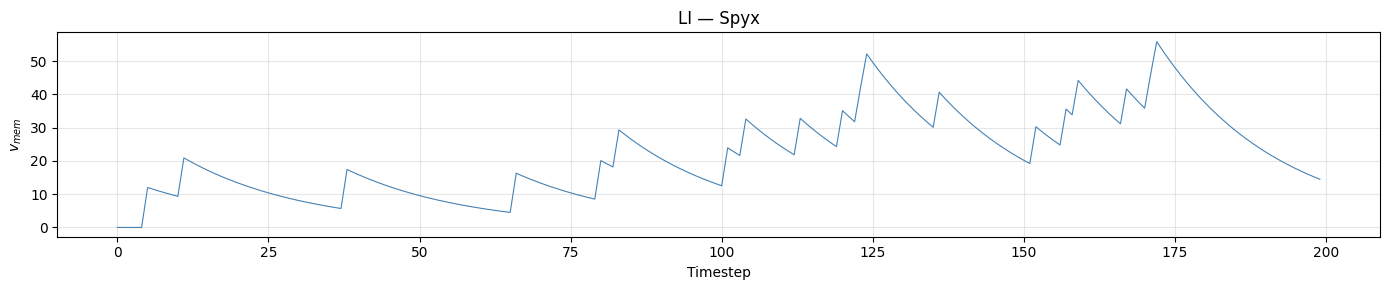

In [15]:
def spyx_li_fn(x):
    # x: (timesteps, inputs)
    core = hk.DeepRNN([
        snn.LI((1,), beta=beta)
    ])
    # dynamic_unroll returns (all_outputs, final_state).
    # LI.__call__ returns (Vout, Vout), so all_outputs IS the V trace.
    v_trace, _ = hk.dynamic_unroll(core, x, core.initial_state(1), time_major=True)
    return v_trace

SNN_LI = hk.without_apply_rng(hk.transform(spyx_li_fn))
params_li = SNN_LI.init(rng=jax_key, x=sample)
spyx_li_v_trace = SNN_LI.apply(params_li, x=sample)

spyx_li_recordings = {
    "v_mem": np.array(spyx_li_v_trace).squeeze(),
}

plot_neuron(
    spyx_li_recordings["v_mem"],
    title="LI — Spyx",
    filename=str(spyx_dir / "li.png"),
)

### LIF — Spyx

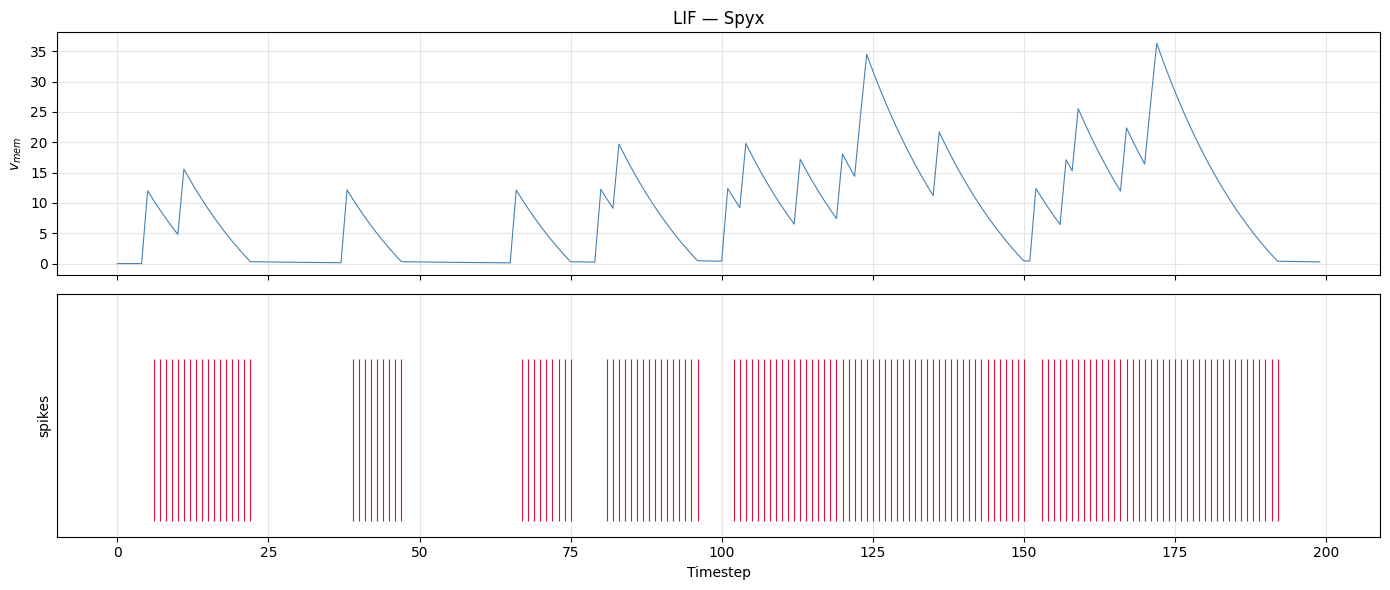

In [16]:
def spyx_lif_fn(x):
    # x: (timesteps, inputs)
    lif = snn.LIF((1,), beta=beta, threshold=v_th)

    # Manual scan to collect both spikes and V trace at each timestep.
    # LIF.__call__ returns (spikes, V_new).
    def step(state, xt):
        spikes, v_new = lif(xt, state)
        return v_new, (spikes, v_new)


    init_state = lif.initial_state(1)
    _, (spike_trace, v_trace) = hk.scan(step, init_state, x)
    return spike_trace, v_trace

SNN_LIF = hk.without_apply_rng(hk.transform(spyx_lif_fn))
params_lif = SNN_LIF.init(rng=jax_key, x=sample)
spyx_lif_spikes, spyx_lif_v = SNN_LIF.apply(params_lif, x=sample)

spyx_lif_recordings = {
    "v_mem":  np.array(spyx_lif_v).squeeze(),
    "spikes": np.array(spyx_lif_spikes).squeeze(),
}

plot_neuron(
    spyx_lif_recordings["v_mem"],
    spyx_lif_recordings["spikes"],
    title="LIF — Spyx",
    filename=str(spyx_dir / "lif.png"),
)

# Combined comparison

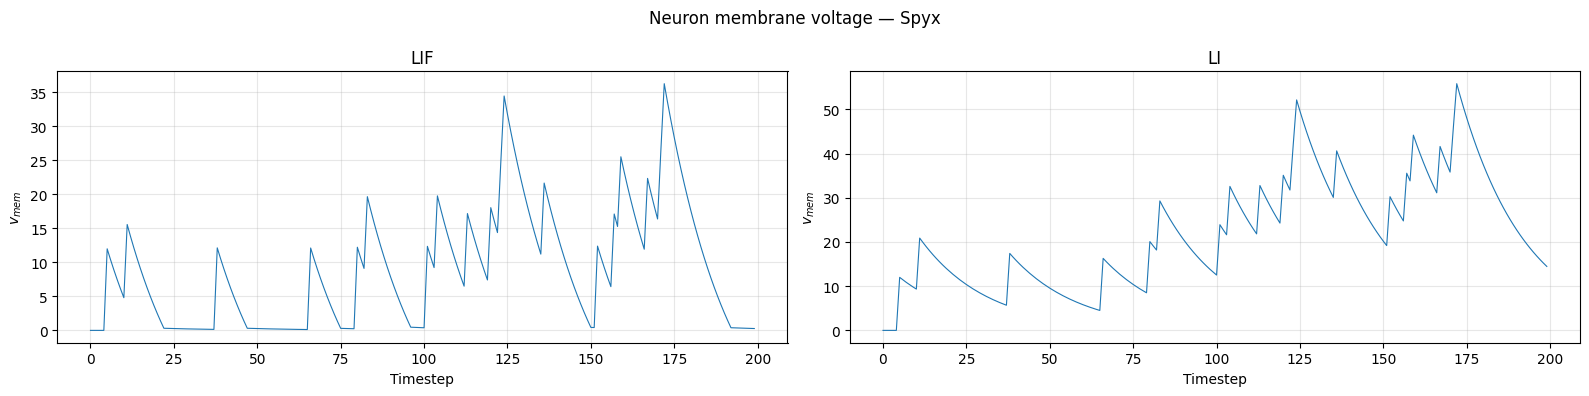

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
fig.suptitle("Neuron membrane voltage — Spyx")

pairs = [
    ("LIF", spyx_lif_recordings["v_mem"]),
    ("LI",  spyx_li_recordings["v_mem"]),
]

for ax, (title, v) in zip(axes.flat, pairs):
    ax.plot(np.asarray(v).squeeze(), linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("$v_{mem}$")
    ax.set_xlabel("Timestep")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(output_dir / "comparison.png"), dpi=150)
plt.show()

# 4. Training a small model in JAX (Spyx)

We train a minimal single-layer model (Linear -> LIF) to classify samples by
spike count (high vs. low activity).

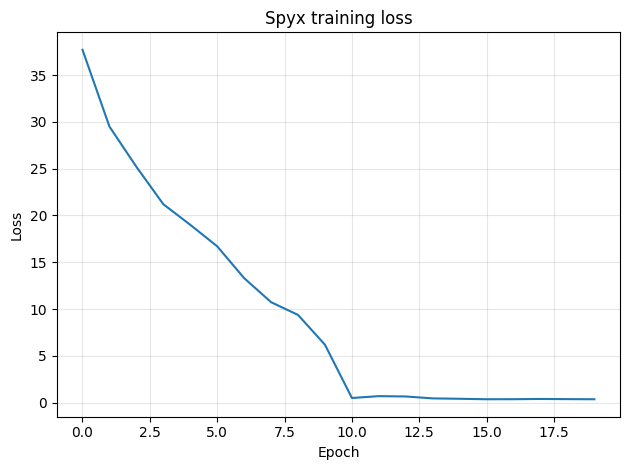

In [18]:

import optax

labels_jax = jnp.array(np.concatenate([
    np.zeros(len(dataset) // 2),
    np.ones(len(dataset) - len(dataset) // 2),
]))

def spyx_train_fn(x):
    x = hk.Linear(1, with_bias=False)(x)
    core = hk.DeepRNN([
        snn.LIF((1,), beta=beta, threshold=v_th)
    ])
    spikes, V = hk.dynamic_unroll(core, x, core.initial_state(1), time_major=True)
    return spikes.sum(axis=0)  # total spike count

SNN_train = hk.without_apply_rng(hk.transform(spyx_train_fn))
train_params = SNN_train.init(rng=jax_key, x=dataset[0])
opt = optax.adam(1e-2)
opt_state = opt.init(train_params)

@jax.jit
def train_step(params, opt_state, x, y):
    def loss_fn(p):
        logits = SNN_train.apply(p, x=x).squeeze()
        return optax.sigmoid_binary_cross_entropy(logits, y).mean()
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = opt.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

spyx_losses = []
for epoch in range(20):
    epoch_loss = 0.0
    for i in range(len(dataset)):
        train_params, opt_state, loss = train_step(
            train_params, opt_state, dataset[i], labels_jax[i]
        )
        epoch_loss += float(loss)
    spyx_losses.append(epoch_loss / len(dataset))

plt.plot(spyx_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Spyx training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(spyx_dir / "training_loss.png"), dpi=150)
plt.show()

# 5. Exporting the files for dataflow accelerator generation

In [19]:
# Build NIR graphs from the Spyx parameters.
# spyx.nir.to_nir expects multi-layer pytrees; for our single-neuron models
# we construct the NIR nodes directly.

beta_np = np.atleast_1d(np.array(params_lif["LIF"]["beta"]))
dt = 1  # Spyx uses dt=1 by convention
tau = dt / (1 - beta_np)

nir_lif_spyx = nir.NIRGraph(
    nodes={
        "input":  nir.Input(input_type=np.array([1])),
        "lif":    nir.LIF(tau=tau, v_threshold=np.ones_like(beta_np),
                          v_leak=np.zeros_like(beta_np), r=beta_np),
        "output": nir.Output(output_type=np.array([1])),
    },
    edges=[("input", "lif"), ("lif", "output")],
)

beta_li_np = np.atleast_1d(np.array(params_li["LI"]["beta"]))
tau_li = dt / (1 - beta_li_np)

nir_li_spyx = nir.NIRGraph(
    nodes={
        "input":  nir.Input(input_type=np.array([1])),
        "li":     nir.LI(tau=tau_li, v_leak=np.zeros_like(beta_li_np), r=beta_li_np),
        "output": nir.Output(output_type=np.array([1])),
    },
    edges=[("input", "li"), ("li", "output")],
)

nir.write(str(spyx_dir / "lif.nir"), nir_lif_spyx)
nir.write(str(spyx_dir / "li.nir"),  nir_li_spyx)

print("Saved NIR graphs to", spyx_dir)

Saved NIR graphs to outputs/spyx


# 6. Exporting the trained classifier

In [20]:
# --- Dataset ---
dataset_np = np.array(dataset)
labels_np  = np.array(labels_jax)
np.savez(str(spyx_dir / "dataset.npz"), inputs=dataset_np, labels=labels_np)
print(f"Dataset inputs : shape={dataset_np.shape}, dtype={dataset_np.dtype}")
print(f"Dataset labels : shape={labels_np.shape}, dtype={labels_np.dtype}")

# --- Accuracy ---
correct = 0
for i in range(len(dataset)):
    spike_count = float(SNN_train.apply(train_params, x=dataset[i]).squeeze())
    pred = int(spike_count > 0.5)
    correct += int(pred == int(labels_np[i]))
accuracy = correct / len(dataset)
print(f"Accuracy over dataset: {correct}/{len(dataset)} = {accuracy:.1%}")

# --- NIR graph ---
# Haiku stores hk.Linear weights as (in_features, out_features); NIR expects (out, in).
W = np.array(train_params["linear"]["w"]).T      # shape (1, 1)
beta_cls = np.atleast_1d(np.array(train_params["LIF"]["beta"]))
tau_cls  = dt / (1 - beta_cls)

# The sinabs pipeline uses norm_input=True: v[t] = alpha*v + (1-alpha)*input.
# Spyx trained with r=beta: v[t] = beta*v + beta*input.
# Scale W so that (1-beta)*W_nir reproduces beta*W_spyx.
r_correction = float(beta_cls[0] / (1.0 - beta_cls[0]))
W_nir = W * r_correction

nir_classifier = nir.NIRGraph(
    nodes={
        "input":  nir.Input(input_type=np.array([1])),
        "linear": nir.Linear(weight=W_nir),
        "lif":    nir.LIF(
                      tau=tau_cls,
                      v_threshold=np.ones_like(beta_cls),
                      v_leak=np.zeros_like(beta_cls),
                      r=np.ones_like(beta_cls),
                  ),
        "output": nir.Output(output_type=np.array([1])),
    },
    edges=[("input", "linear"), ("linear", "lif"), ("lif", "output")],
)
nir.write(str(spyx_dir / "classifier.nir"), nir_classifier)
print(f"Saved NIR classifier to {spyx_dir / 'classifier.nir'}")

# --- Source recordings (representative sample, for add_recording in notebook 2) ---
def spyx_record_fn(x):
    h = hk.Linear(1, with_bias=False)(x)
    lif = snn.LIF((1,), beta=beta, threshold=v_th)
    def step(state, xt):
        spikes, v_new = lif(xt, state)
        return v_new, (spikes, v_new)
    _, (spike_trace, v_trace) = hk.scan(step, lif.initial_state(1), h)
    return h, spike_trace, v_trace

SNN_record = hk.without_apply_rng(hk.transform(spyx_record_fn))
h_rec, spikes_rec, vmem_rec = SNN_record.apply(train_params, x=dataset[0])

np.savez(
    str(spyx_dir / "source_recordings.npz"),
    linear_input  = np.array(dataset[0]),   # (T, 1)
    linear_output = np.array(h_rec),        # (T, 1)
    lif_output    = np.array(spikes_rec),   # (T, 1)
    lif_v_mem     = np.array(vmem_rec),     # (T, 1)
    accuracy      = np.array(accuracy),
)
print(f"Saved source recordings to {spyx_dir / 'source_recordings.npz'}")

Dataset inputs : shape=(10, 200, 1), dtype=float32
Dataset labels : shape=(10,), dtype=float32
Accuracy over dataset: 10/10 = 100.0%
Saved NIR classifier to outputs/spyx/classifier.nir
Saved source recordings to outputs/spyx/source_recordings.npz
